# CNN Emotion Classification - Experiment

## Sample Images

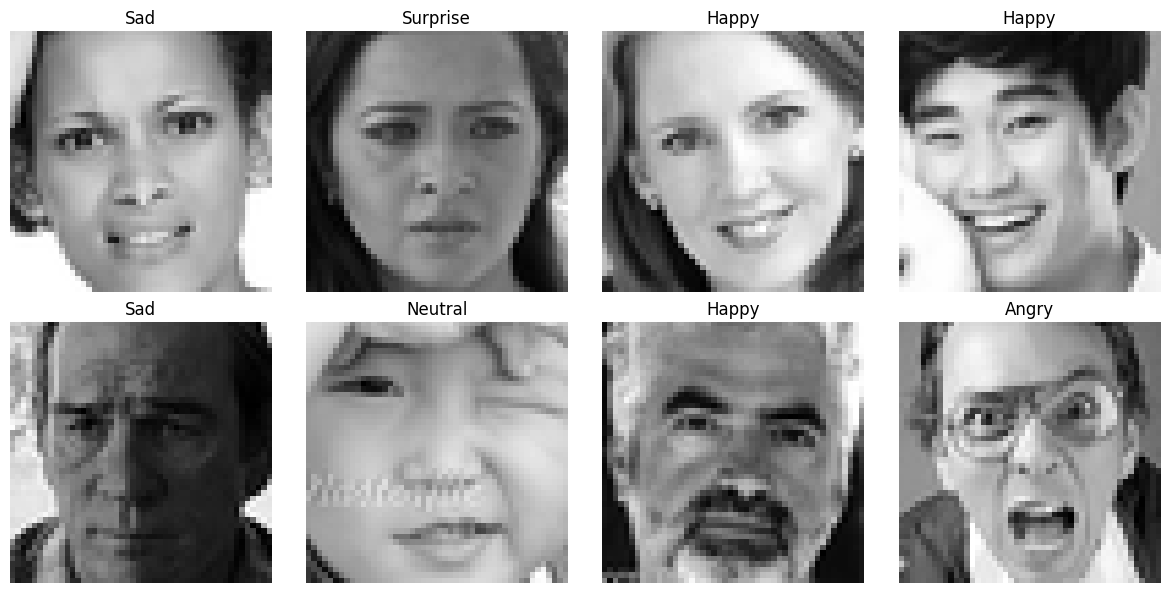

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(FERDataset.class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Training Summary

Set `MODEL_NAME` to `"simple"` or `"vgg"`. Artifacts live under `results/<model>/` after:

```bash
python src/main.py --model simple
python src/main.py --model vgg
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from main import MODELS, get_results_dir, load_history

# Switch between "simple" and "vgg"
MODEL_NAME = "vgg"

history = load_history(MODEL_NAME, ROOT)
train_losses = history["train_losses"]
val_losses = history["val_losses"]
val_accuracies = history["val_accuracies"]

# Load every trained model that has metrics (for comparison plots)
all_histories = {}
for name in MODELS:
    try:
        all_histories[name] = load_history(name, ROOT)
    except FileNotFoundError:
        pass

print(f"Active model: {MODEL_NAME} ({get_results_dir(MODEL_NAME, ROOT)})")
print(f"Available results: {list(all_histories)}")
print(f"Best val accuracy ({MODEL_NAME}): {val_accuracies.max():.4f}")


Active model: vgg (/Users/epimetheus012/Desktop/cnn-emotion-gradcam/results/vgg)
Available results: ['simple', 'vgg']
Best val accuracy (vgg): 0.5846


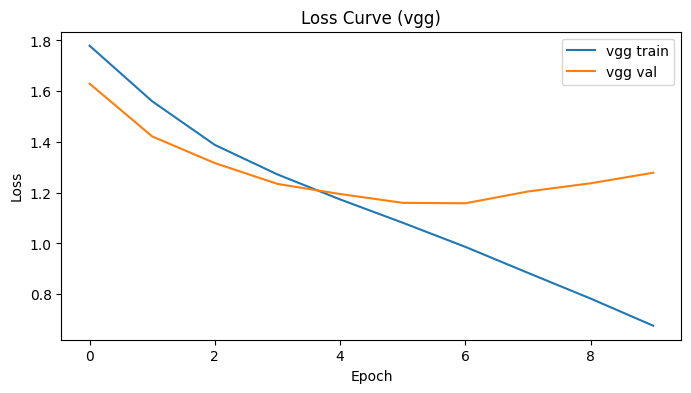

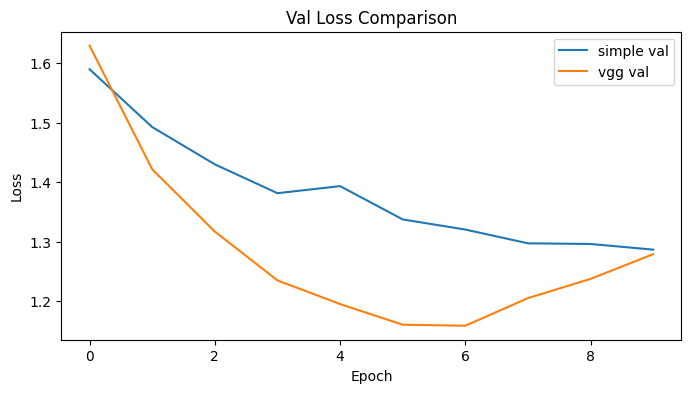

In [2]:
# Active model curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label=f"{MODEL_NAME} train")
plt.plot(val_losses, label=f"{MODEL_NAME} val")
plt.legend()
plt.title(f"Loss Curve ({MODEL_NAME})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Side-by-side comparison when multiple models are trained
if len(all_histories) > 1:
    plt.figure(figsize=(8, 4))
    for name, hist in all_histories.items():
        plt.plot(hist["val_losses"], label=f"{name} val")
    plt.legend()
    plt.title("Val Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


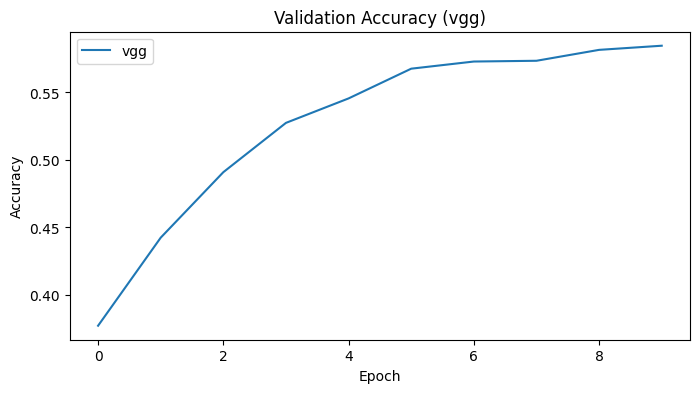

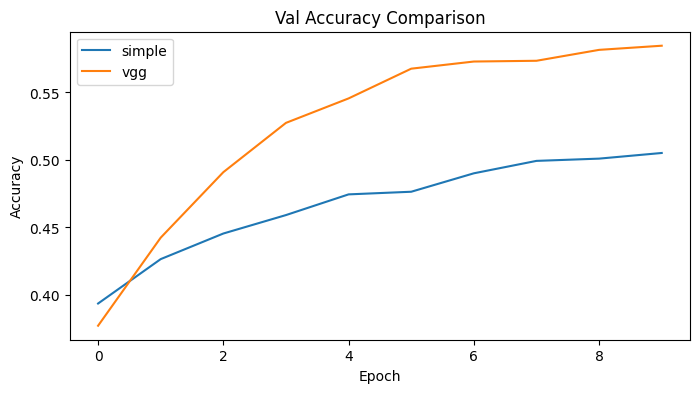

Best val accuracy by model:
  simple: 0.5052
  vgg: 0.5846


In [3]:
plt.figure(figsize=(8, 4))
plt.plot(val_accuracies, label=f"{MODEL_NAME}")
plt.legend()
plt.title(f"Validation Accuracy ({MODEL_NAME})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

if len(all_histories) > 1:
    plt.figure(figsize=(8, 4))
    for name, hist in all_histories.items():
        plt.plot(hist["val_accuracies"], label=name)
    plt.legend()
    plt.title("Val Accuracy Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    print("Best val accuracy by model:")
    for name, hist in all_histories.items():
        print(f"  {name}: {hist['val_accuracies'].max():.4f}")


In [4]:
print(f"Best Val Accuracy ({MODEL_NAME}): {val_accuracies.max():.4f}")

Best Val Accuracy (vgg): 0.5846


## Predictions

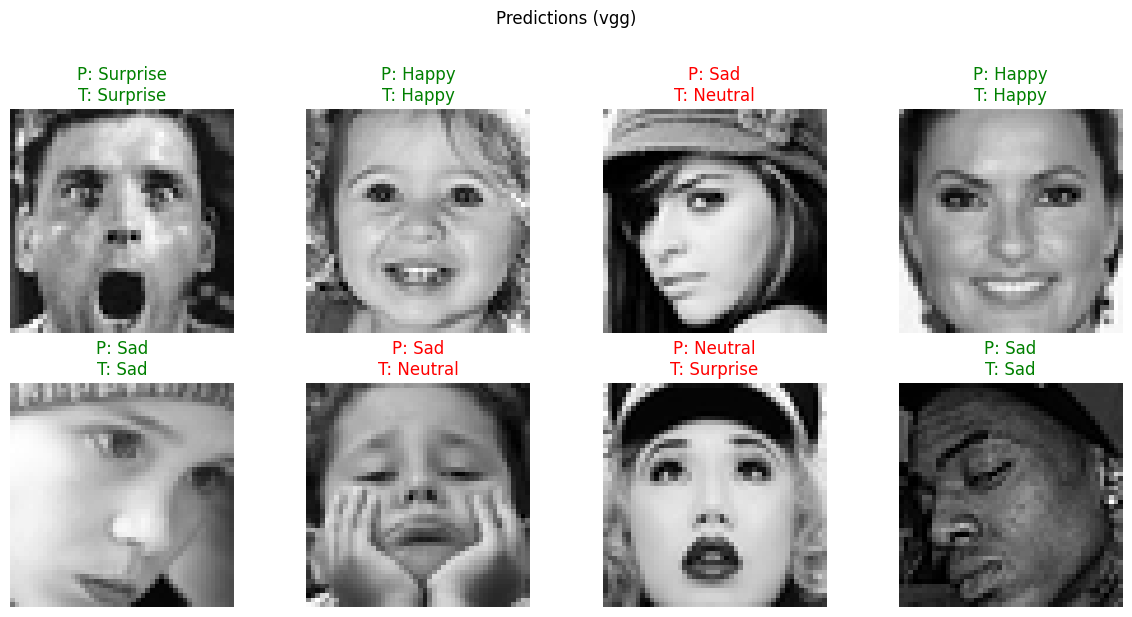

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import random
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, get_device, load_trained_model

# Uses MODEL_NAME from the Training Summary setup cell
val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(MODEL_NAME, device, ROOT)

indices = random.sample(range(len(val_dataset)), 8)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")

    title = f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}"
    color = "green" if pred == label else "red"
    plt.title(title, color=color)

    plt.axis("off")

plt.suptitle(f"Predictions ({MODEL_NAME})", y=1.02)
plt.tight_layout()
plt.show()


## Confusion Matrix

[[197   7  62  42  93  14  52]
 [  7  23   6   6  11   0   3]
 [ 33   0 224  26 108  47  58]
 [ 18   0  29 716  50  19  63]
 [ 62   0 101  49 313  15 113]
 [ 13   0  35  22  17 312  16]
 [ 49   1  57  60 114  13 313]]


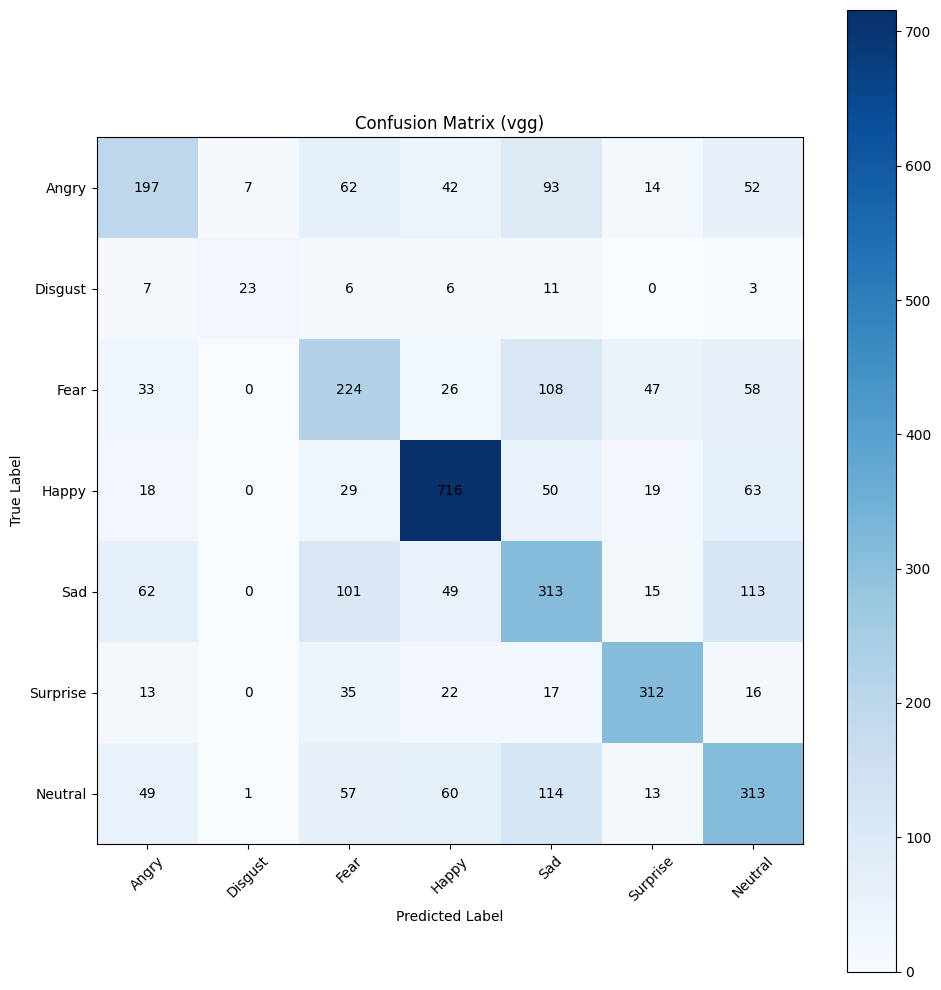

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

import sys
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, load_predictions

class_names = list(FERDataset.class_names)

y_true, y_pred = load_predictions(MODEL_NAME, ROOT)

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print(cm)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({MODEL_NAME})")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"), ha="center", va="center")

plt.tight_layout()
plt.show()


### Observations
- Happy has the strongest performance.
- Disjust has the least recognition.
- Negative emotions, such as anger, fear, and sadness, are often confused.

### Confusion pair analysis

In [7]:
import sys
from pathlib import Path

import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))
from main import FERDataset, get_device, load_trained_model

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(MODEL_NAME, device, ROOT)

target_true = 2   # Fear
target_pred = 5   # Surprise

pair_indices = []

for idx in range(len(val_dataset)):
    image, label = val_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    if label == target_true and pred == target_pred:
        pair_indices.append(idx)

print(f"Found {len(pair_indices)} {FERDataset.class_names[target_true]}→{FERDataset.class_names[target_pred]} pairs ({MODEL_NAME})")


Found 47 Fear→Surprise pairs (vgg)


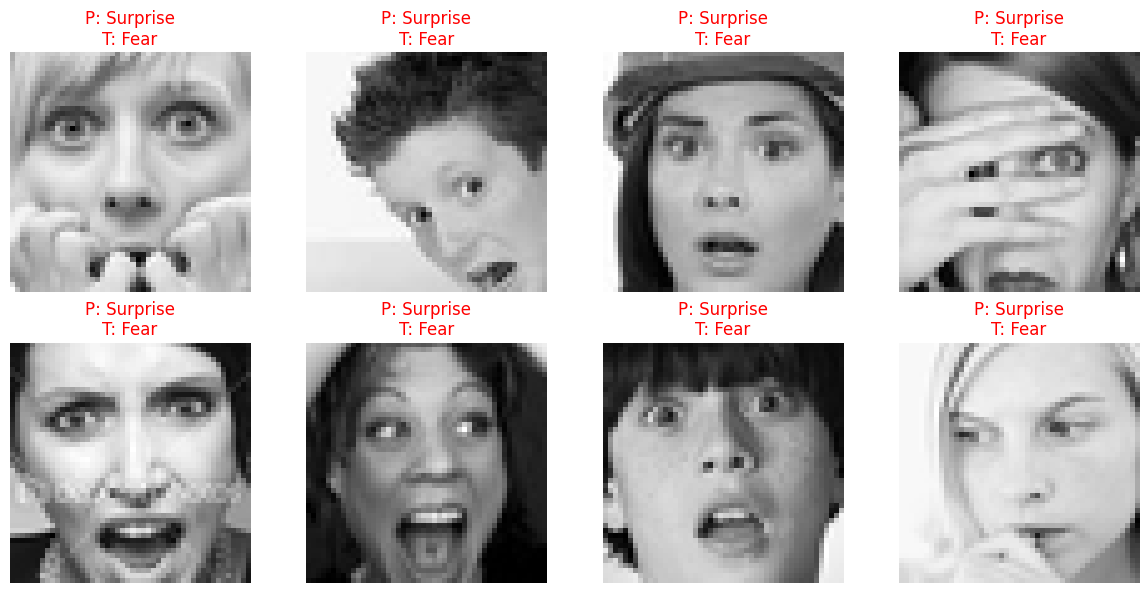

In [8]:
import matplotlib.pyplot as plt

sample_pair = pair_indices[:8]

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_pair):
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    plt.subplot(2, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"P: {FERDataset.class_names[pred]}\nT: {FERDataset.class_names[label]}", color="red")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM Visualization

In [9]:
import sys
from pathlib import Path
import random
import matplotlib.pyplot as plt
import torch

_root = Path.cwd()
ROOT = _root.parent if _root.name == "notebooks" else _root
sys.path.insert(0, str(ROOT / "src"))

from main import FERDataset, get_device, load_trained_model, get_gradcam_layer
from gradcam import GradCAM


Model output shape: (1, 7)
Saved activation shape: (1, 256, 12, 12)
Saved gradient shape: (1, 256, 12, 12)
Raw CAM shape: (12, 12)
Resized CAM shape: (48, 48)


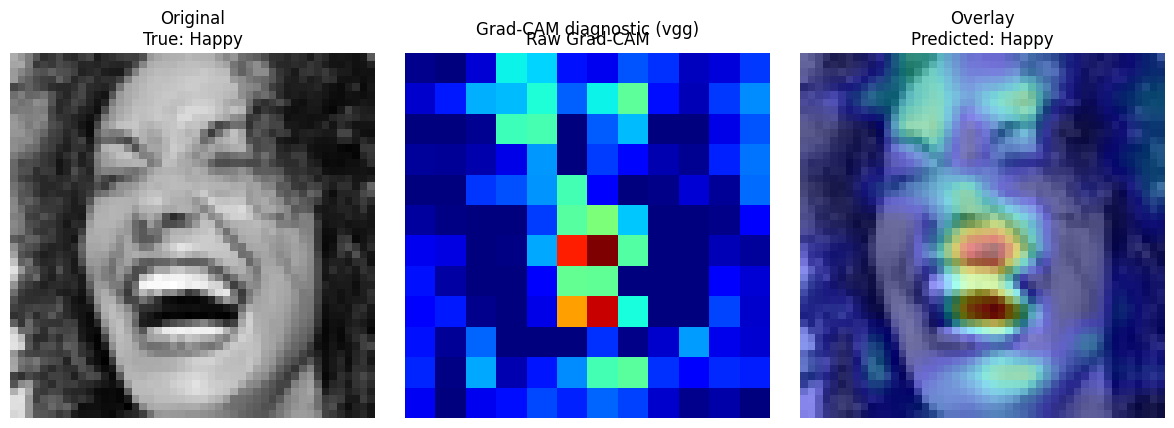

In [10]:
class_names = list(FERDataset.class_names)

val_dataset = FERDataset(ROOT / "data" / "fer2013.csv", split="PublicTest")
device = get_device()
model = load_trained_model(MODEL_NAME, device, ROOT)

# The architecture-specific target layer is selected outside GradCAM.
gradcam = GradCAM(model, get_gradcam_layer(model, MODEL_NAME))

idx = random.randrange(len(val_dataset))
image, label = val_dataset[idx]
input_tensor = image.unsqueeze(0).to(device)

try:
    # If class_idx is omitted, Grad-CAM explains the model's top prediction.
    raw_cam, pred = gradcam.generate(input_tensor)
    fig, axes, resized_cam = gradcam.visualize(
        image,
        raw_cam,
        alpha=0.4,
        print_diagnostics=True,
    )
    axes[0].set_title(f"Original\nTrue: {class_names[label]}")
    axes[2].set_title(f"Overlay\nPredicted: {class_names[pred]}")
    fig.suptitle(f"Grad-CAM diagnostic ({MODEL_NAME})", y=1.03)
    plt.show()
finally:
    gradcam.remove_hooks()
